<a href="https://colab.research.google.com/github/matildacr/act4/blob/main/Actividad4_optimizacion_ensamble_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 4 — Optimización de un modelo de ensamble

**Algoritmos de aprendizaje automático**

Este notebook optimiza un modelo de ensamble de forma controlada y comprueba, **bajo las mismas condiciones**, si las modificaciones producen una ventaja real frente a una línea base.

## 0. Configuración y reproducibilidad

Fijamos una **semilla única** (`RANDOM_STATE = 42`) que se reutiliza en la partición, en los modelos y en la validación cruzada.

In [6]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score, precision_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Librerías cargadas", RANDOM_STATE)

Librerías cargadas 42


## 1. Descripción del problema y del dataset

| Campo | Detalle |
|---|---|
| **Nombre del dataset** | Breast Cancer Wisconsin (Diagnostic) |
| **Fuente** | Repositorio UCI Machine Learning. Página del dataset: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic · Archivo de datos directo: https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data |
| **Tipo de problema** | Clasificación binaria |
| **Variable objetivo** | Diagnóstico del tumor: **maligno** vs. **benigno** |
| **Qué representa cada observación** | Un tumor de mama. Cada fila resume una imagen digitalizada de una punción con aguja fina (FNA) mediante 30 medidas numéricas del núcleo celular (radio, textura, perímetro, área, suavidad, etc.), en sus versiones *media*, *error estándar* y *peor valor*. |
| **Nº de observaciones / variables** | 569 tumores / 30 variables predictoras, todas numéricas continuas |

**Convención de clases.** El dataset original codifica `maligno = 0` y `benigno = 1`. Para que las métricas orientadas a la clase positiva tengan un sentido clínico directo, **re-etiquetamos** de modo que la clase positiva (`1`) sea **maligno** (el evento que interesa detectar) y `0` sea benigno.

### Métrica principal: **F1-score** (de la clase maligna)

**Justificación.** Es un problema de diagnóstico médico donde los dos errores tienen costos asimétricos pero ambos importan:

- Un **falso negativo** (declarar benigno un tumor maligno) es el error más grave: se omite un cáncer. Esto se penaliza vía **recall**.
- Un **falso positivo** genera procedimientos y angustia innecesarios. Esto se penaliza vía **precision**.

Además, las clases están **moderadamente desbalanceadas** (~37 % maligno / ~63 % benigno), por lo que el *accuracy* puede resultar engañoso. El **F1-score** combina precision y recall en un solo número y es robusto ante ese desbalance, por eso es la métrica principal.

**Métrica complementaria: ROC-AUC**, que mide la capacidad de discriminación del modelo **independiente del umbral** de decisión. También reportamos recall, precision y accuracy como apoyo.

## 2. Carga y preparación de los datos

Los datos se cargan desde el archivo **`breast_cancer_procesado.csv`**. La celda es robusta: si el archivo no está presente, lo **descarga automáticamente** desde el repositorio UCI y lo reconstruye, de modo que el notebook funciona igual en local o en Google Colab.

> **En Google Colab:** arrastra `breast_cancer_procesado.csv` al panel de **Archivos** (icono de carpeta a la izquierda) antes de ejecutar. Si no lo subes, la celda lo descargará sola desde la UCI.

Luego separamos predictoras (`X`) y objetivo (`y`) y revisamos **tipos de datos, valores faltantes, duplicados y distribución de la variable objetivo**.

In [7]:
import os

base = ["radius", "texture", "perimeter", "area", "smoothness", "compactness",
        "concavity", "concave points", "symmetry", "fractal dimension"]
columnas = (["id", "diagnosis"]
            + ["mean " + b for b in base]
            + [b + " error" for b in base]
            + ["worst " + b for b in base])

fuente = "wdbc.csv" if os.path.exists("wdbc.csv") else \
    "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

df = pd.read_csv(fuente, header=None, names=columnas)
df["target"] = (df["diagnosis"] == "M").astype(int)          # 1 = maligno, 0 = benigno
df["target_label"] = df["diagnosis"].map({"M": "maligno", "B": "benigno"})
df = df.drop(columns="diagnosis")

target_names = {0: "benigno", 1: "maligno"}
X = df.drop(columns=["id", "target", "target_label"])
y = df["target"]

print("Fuente:", fuente)
print("Dimensiones de X:", X.shape)
print("Nº de variables predictoras:", X.shape[1])
X.head()

Fuente: wdbc.csv
Dimensiones de X: (569, 30)
Nº de variables predictoras: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# --- Revisión de calidad de datos ---
print("Tipos de datos (todas numéricas continuas):")
print(X.dtypes.value_counts(), "\n")

print("Valores faltantes totales:", int(X.isna().sum().sum()))
print("Filas duplicadas:", int(df.duplicated().sum()), "\n")

dist = y.value_counts().sort_index()
prop = y.value_counts(normalize=True).sort_index().round(3)
resumen_y = pd.DataFrame({"conteo": dist, "proporción": prop})
resumen_y.index = [target_names[i] for i in resumen_y.index]
print("Distribución de la variable objetivo:")
print(resumen_y)

Tipos de datos (todas numéricas continuas):
float64    30
Name: count, dtype: int64 

Valores faltantes totales: 0
Filas duplicadas: 0 

Distribución de la variable objetivo:
         conteo  proporción
benigno     357       0.627
maligno     212       0.373


**Lectura de la revisión.** No hay valores faltantes ni filas duplicadas, y todas las variables son numéricas, así que no se requiere imputación ni codificación de categóricas. Sin embargo, las variables están en **escalas muy distintas** (p. ej. `area` llega a miles mientras `smoothness` es < 1), por lo que aplicamos **estandarización dentro de un pipeline**. El objetivo está **moderadamente desbalanceado**, lo que refuerza el uso de F1 y motiva la **estratificación** al partir.

In [9]:
# --- Partición entrenamiento / prueba: 80/20, semilla fija, estratificada ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} filas   |   Prueba: {X_test.shape[0]} filas")
print("Proporción de maligno (train):", round(y_train.mean(), 3),
      "| (test):", round(y_test.mean(), 3))
print("La estratificación conserva la proporción de clases en ambos conjuntos.")

Entrenamiento: 455 filas   |   Prueba: 114 filas
Proporción de maligno (train): 0.374 | (test): 0.368
La estratificación conserva la proporción de clases en ambos conjuntos.


## 3. Modelo base (ensamble)

Construimos la línea base con **Random Forest** dentro de un `Pipeline` que primero estandariza. Usamos una **configuración inicial razonable y documentada** (`n_estimators=200`, resto por defecto). Registramos métrica principal, métrica complementaria, número de características y tiempo de entrenamiento.


In [10]:
def evaluar(modelo, X_te, y_te):
    pred = modelo.predict(X_te)
    proba = modelo.predict_proba(X_te)[:, 1]
    return {
        "F1 (principal)": f1_score(y_te, pred),
        "ROC-AUC (compl.)": roc_auc_score(y_te, proba),
        "Recall": recall_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Accuracy": accuracy_score(y_te, pred),
    }

# --- Modelo base ---
pipe_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])

t0 = time.perf_counter()
pipe_base.fit(X_train, y_train)
t_base = time.perf_counter() - t0

n_feat_base = X_train.shape[1]
met_base = evaluar(pipe_base, X_test, y_test)

print(f"Nº de características: {n_feat_base}")
print(f"Tiempo de entrenamiento: {t_base:.3f} s\n")
print("Métricas en prueba (modelo base):")
for k, v in met_base.items():
    print(f"  {k:18s}: {v:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, pipe_base.predict(X_test),
                            target_names=["benigno", "maligno"]))

Nº de características: 30
Tiempo de entrenamiento: 1.113 s

Métricas en prueba (modelo base):
  F1 (principal)    : 0.9500
  ROC-AUC (compl.)  : 0.9942
  Recall            : 0.9048
  Precision         : 1.0000
  Accuracy          : 0.9649

Reporte de clasificación:
              precision    recall  f1-score   support

     benigno       0.95      1.00      0.97        72
     maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



## 4. Selección de características

Antes de reducir, exploramos la **redundancia** entre variables con un mapa de correlaciones. El dataset repite cada medida en tres versiones (media / error / peor), por lo que se anticipan bloques muy correlacionados.

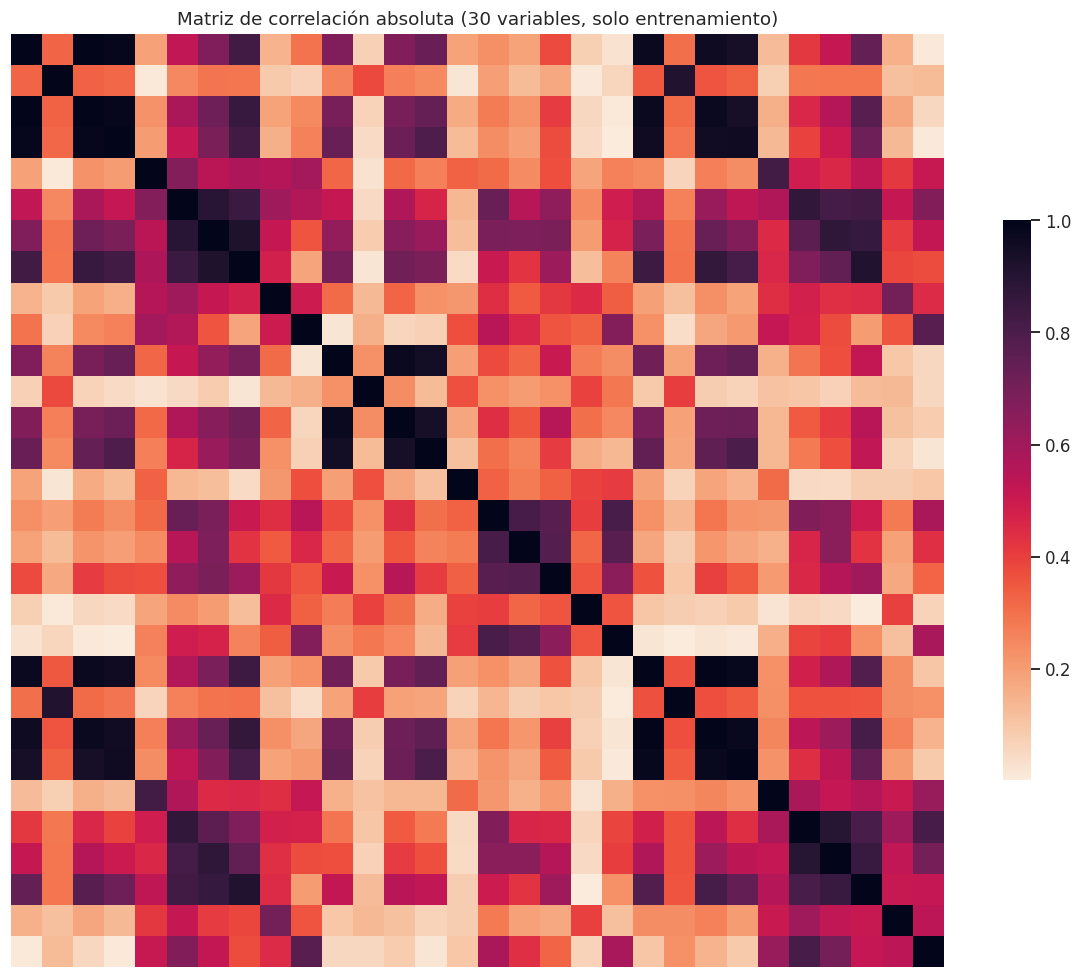

Pares de variables con |correlación| > 0.90: 21


In [11]:
corr = X_train.corr().abs()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="rocket_r", square=True, cbar_kws={"shrink": .6},
            xticklabels=False, yticklabels=False)
plt.title("Matriz de correlación absoluta (30 variables, solo entrenamiento)")
plt.tight_layout()
plt.show()

# Cuántos pares presentan correlación muy alta
alta = (np.triu(corr.values, k=1) > 0.90).sum()
print(f"Pares de variables con |correlación| > 0.90: {alta}")

### Técnica aplicada: `SelectFromModel` con importancias de Random Forest

- **Criterio.** Se entrena un Random Forest y se conservan las variables cuya **importancia supera la mediana** de todas las importancias (`threshold="median"`). Es un método **embebido**, coherente con el ensamble que ya usamos, y —a diferencia de PCA— **preserva la interpretación** de las variables originales (podemos nombrarlas).
- **Sin fuga de información.** El selector va **dentro del pipeline**, por lo que se ajusta únicamente con los datos de entrenamiento (y, más adelante, solo con los *folds* de entrenamiento durante la validación cruzada). El conjunto de prueba nunca interviene en la selección.
- **Efecto esperado sobre la representación.** Con el umbral en la mediana se conserva aproximadamente **la mitad** de las variables, eliminando las redundantes/poco informativas y reduciendo la dimensionalidad sin cambiar el significado de las que quedan.

In [12]:
selector_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)

pipe_sel = Pipeline([
    ("scaler", StandardScaler()),
    ("sel", SelectFromModel(estimator=selector_rf, threshold="median")),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])

t0 = time.perf_counter()
pipe_sel.fit(X_train, y_train)
t_sel = time.perf_counter() - t0

# Variables conservadas
mask = pipe_sel.named_steps["sel"].get_support()
feat_kept = X_train.columns[mask].tolist()
n_feat_sel = len(feat_kept)
met_sel = evaluar(pipe_sel, X_test, y_test)

print(f"Características conservadas: {n_feat_sel} de {X_train.shape[1]}")
print(f"Tiempo de entrenamiento: {t_sel:.3f} s\n")
print("Variables conservadas:")
for f in feat_kept:
    print("  -", f)

Características conservadas: 15 de 30
Tiempo de entrenamiento: 2.001 s

Variables conservadas:
  - mean radius
  - mean texture
  - mean perimeter
  - mean area
  - mean compactness
  - mean concavity
  - mean concave points
  - area error
  - worst radius
  - worst texture
  - worst perimeter
  - worst area
  - worst compactness
  - worst concavity
  - worst concave points


### Comparación: modelo base vs. modelo con selección

In [13]:
tabla_2 = pd.DataFrame([
    {"Configuración": "Modelo base",
     "Nº características": n_feat_base,
     "F1 (principal)": met_base["F1 (principal)"],
     "ROC-AUC (compl.)": met_base["ROC-AUC (compl.)"],
     "Tiempo (s)": t_base},
    {"Configuración": "Modelo con selección",
     "Nº características": n_feat_sel,
     "F1 (principal)": met_sel["F1 (principal)"],
     "ROC-AUC (compl.)": met_sel["ROC-AUC (compl.)"],
     "Tiempo (s)": t_sel},
])
tabla_2.round(4)

,Configuración,Nº características,F1 (principal),ROC-AUC (compl.),Tiempo (s)
0,Modelo base,30,0.950,0.9942,1.1132
1,Modelo con selección,15,0.963,0.9960,2.0012


**Interpretación.** Con **la mitad de las variables**, el modelo con selección mantiene un F1 y un ROC-AUC prácticamente iguales a los de la línea base. No se trata aquí de una mejora grande de la métrica, sino de **conservar el desempeño con menor complejidad**: un modelo más ligero, más fácil de interpretar y de explicar clínicamente (menos mediciones necesarias), sin pérdida relevante de información.

## 5. Ajuste de hiperparámetros con validación cruzada

Sobre el pipeline con selección, ajustamos hiperparámetros del Random Forest con **`GridSearchCV`**. El espacio de búsqueda es **acotado y viable**:

- `n_estimators`: número de árboles.
- `max_depth`: profundidad máxima (controla el sobreajuste).
- `min_samples_split`: mínimo de muestras para dividir un nodo.
- `max_features`: nº de variables candidatas por división.

**Estrategia de validación:** `StratifiedKFold` de **5 particiones** (mantiene la proporción de clases en cada *fold*), con **F1** como métrica de selección. Los hiperparámetros se eligen **solo con validación cruzada sobre entrenamiento**; el conjunto de prueba **no** participa.

In [14]:
param_grid = {
    "clf__n_estimators":      [200, 400],
    "clf__max_depth":         [None, 6, 10],
    "clf__min_samples_split": [2, 5],
    "clf__max_features":      ["sqrt", 0.5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe_sel,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

t0 = time.perf_counter()
grid.fit(X_train, y_train)
t_grid = time.perf_counter() - t0

print(f"Combinaciones evaluadas: {len(grid.cv_results_['params'])}  x 5 folds")
print(f"Tiempo total de búsqueda: {t_grid:.1f} s")
print(f"Mejor F1 en validación cruzada: {grid.best_score_:.4f}\n")
print("Mejor configuración encontrada:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

Combinaciones evaluadas: 24  x 5 folds
Tiempo total de búsqueda: 168.2 s
Mejor F1 en validación cruzada: 0.9517

Mejor configuración encontrada:
  clf__max_depth: None
  clf__max_features: 0.5
  clf__min_samples_split: 2
  clf__n_estimators: 400


In [15]:
# Tabla de hiperparámetros: valores explorados y mejor valor
def limpio(nombre): return nombre.replace("clf__", "")
tabla_hp = pd.DataFrame([
    {"Hiperparámetro": limpio(k),
     "Valores explorados": ", ".join(map(str, v)),
     "Mejor valor": str(grid.best_params_[k])}
    for k, v in param_grid.items()
])
tabla_hp

,Hiperparámetro,Valores explorados,Mejor valor
0,n_estimators,"200, 400",400
1,max_depth,"None, 6, 10",None
2,min_samples_split,"2, 5",2
3,max_features,"sqrt, 0.5",0.5


**Por qué validación cruzada y no una sola división.** Una única partición de validación estima el desempeño con **un solo subconjunto**, y ese número depende mucho de qué ejemplos cayeron ahí (alta varianza). La validación cruzada de 5 particiones entrena y valida **5 veces** sobre subconjuntos distintos y **promedia**, lo que da una estimación **más estable y menos dependiente del azar** para comparar configuraciones.

**Por qué se reserva el conjunto de prueba.** Si usáramos el conjunto de prueba para elegir hiperparámetros, ese conjunto dejaría de ser independiente y el desempeño reportado quedaría **optimistamente sesgado**. Por eso las decisiones de ajuste se toman **solo con validación cruzada sobre entrenamiento**, y la prueba se usa **una única vez**, al final, como evaluación imparcial.

## 6. Evaluación final y comparación de los tres modelos

`GridSearchCV` con `refit=True` ya reentrenó el mejor modelo con **todos** los datos de entrenamiento. Lo evaluamos sobre el conjunto de prueba y lo comparamos con los dos anteriores, **con la misma partición, semilla y métricas**.

In [16]:
modelo_opt = grid.best_estimator_
met_opt = evaluar(modelo_opt, X_test, y_test)
n_feat_opt = int(modelo_opt.named_steps["sel"].get_support().sum())

tabla_final = pd.DataFrame([
    {"Modelo": "Base",       "F1 (principal)": met_base["F1 (principal)"],
     "ROC-AUC (compl.)": met_base["ROC-AUC (compl.)"], "Características": n_feat_base, "Tiempo (s)": t_base},
    {"Modelo": "Reducido",   "F1 (principal)": met_sel["F1 (principal)"],
     "ROC-AUC (compl.)": met_sel["ROC-AUC (compl.)"], "Características": n_feat_sel, "Tiempo (s)": t_sel},
    {"Modelo": "Optimizado", "F1 (principal)": met_opt["F1 (principal)"],
     "ROC-AUC (compl.)": met_opt["ROC-AUC (compl.)"], "Características": n_feat_opt, "Tiempo (s)": t_grid},
])
tabla_final.round(4)

,Modelo,F1 (principal),ROC-AUC (compl.),Características,Tiempo (s)
0,Base,0.950,0.9942,30,1.1132
1,Reducido,0.963,0.9960,15,2.0012
2,Optimizado,0.963,0.9957,15,168.1762


### Visualizaciones comparativas

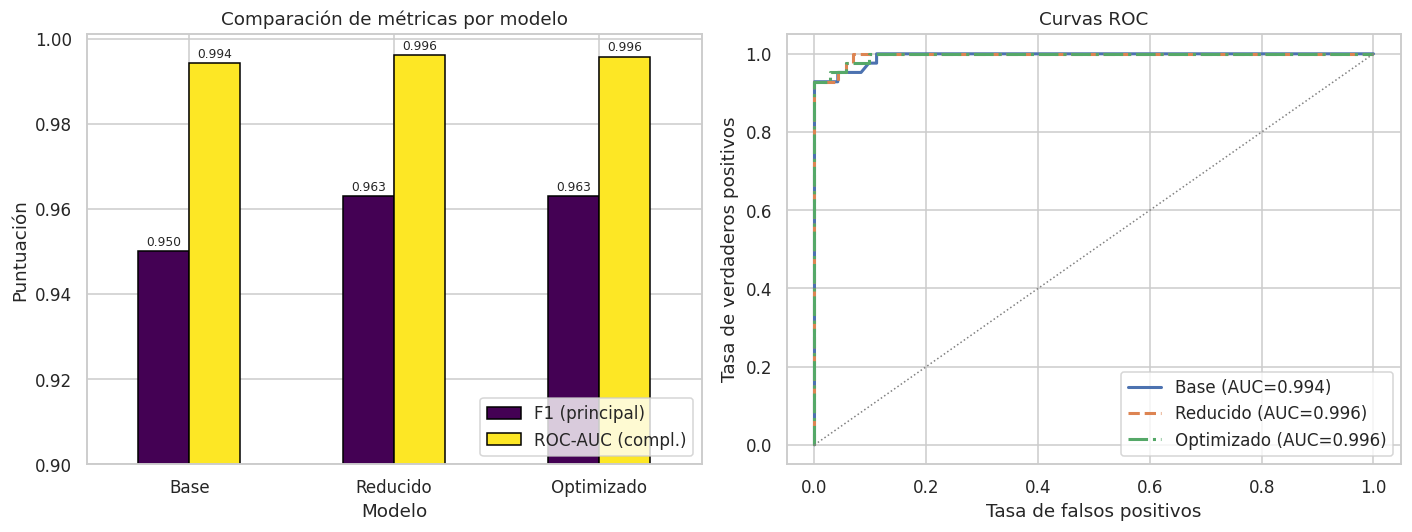

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Comparación de métricas
comp = tabla_final.set_index("Modelo")[["F1 (principal)", "ROC-AUC (compl.)"]]
comp.plot(kind="bar", ax=axes[0], rot=0, colormap="viridis", edgecolor="black")
axes[0].set_title("Comparación de métricas por modelo")
axes[0].set_ylim(0.90, 1.001)
axes[0].set_ylabel("Puntuación")
axes[0].legend(loc="lower right")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.3f", padding=2, fontsize=8)

# (b) Curvas ROC de los tres modelos
for nombre, modelo, t in [("Base", pipe_base, "-"),
                          ("Reducido", pipe_sel, "--"),
                          ("Optimizado", modelo_opt, "-.")]:
    proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, t, lw=2, label=f"{nombre} (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="grey", lw=1, ls=":")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curvas ROC")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

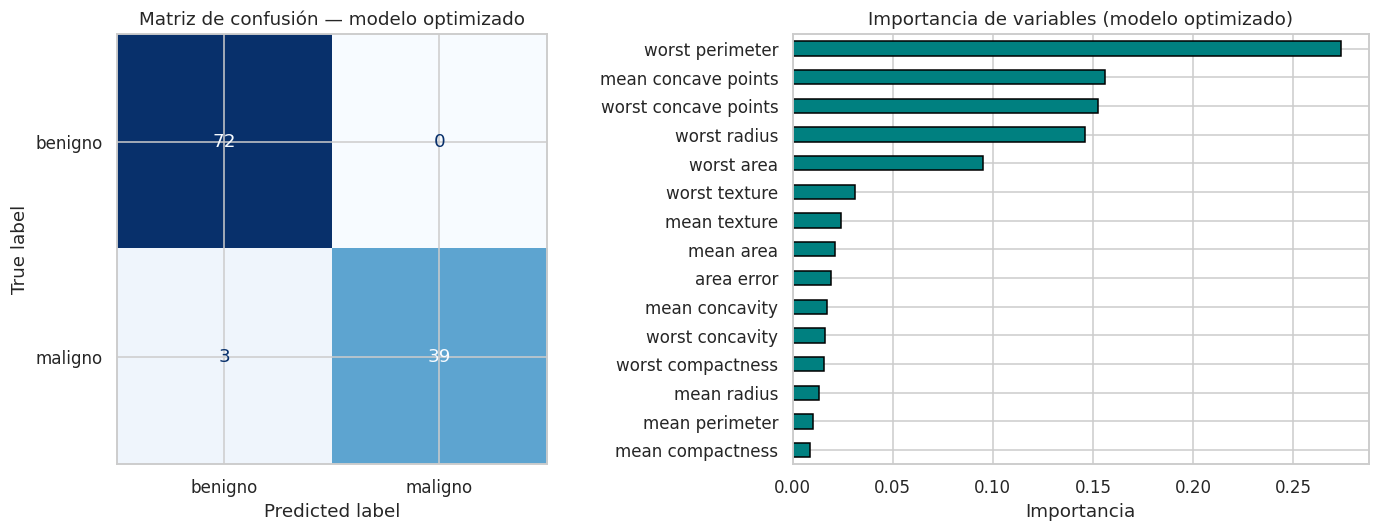

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (c) Matriz de confusión del modelo optimizado
cm = confusion_matrix(y_test, modelo_opt.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["benigno", "maligno"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusión — modelo optimizado")

# (d) Importancia de las variables conservadas (modelo optimizado)
rf_final = modelo_opt.named_steps["clf"]
imp = pd.Series(rf_final.feature_importances_, index=feat_kept).sort_values()
imp.plot(kind="barh", ax=axes[1], color="teal", edgecolor="black")
axes[1].set_title("Importancia de variables (modelo optimizado)")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()

### Análisis del equilibrio precisión — generalización — interpretabilidad — costo

- **¿La mejora justifica el costo?** Pasar de la línea base al modelo optimizado implicó una **búsqueda con validación cruzada** (mucho más costosa en tiempo que un solo entrenamiento) a cambio de una mejora **marginal** en las métricas de prueba. En un entorno de recursos limitados, esa ganancia puede no justificar el costo; el mayor beneficio práctico vino de la **selección de características**, no del ajuste fino.
- **Interpretabilidad.** La selección conservó variables originales con significado clínico y **redujo a la mitad** las mediciones necesarias; esto es una ventaja real de interpretabilidad y de costo de adquisición de datos frente a usar las 30 variables (y frente a PCA, que habría destruido el significado de cada eje).
- **Sensibilidad al escalamiento.** Random Forest es esencialmente insensible al escalamiento; mantener el `StandardScaler` no perjudica y deja el pipeline listo por si se comparara con modelos que sí lo requieren.
- **Estabilidad y sobreajuste.** La validación cruzada de 5 particiones da una estimación estable, y el uso de `max_depth`/`min_samples_split` limita el crecimiento de los árboles, conteniendo el riesgo de sobreajuste. La cercanía entre el F1 de validación cruzada y el de prueba sugiere **buena generalización**.

## 7. Conclusión

- **¿Qué modificación produjo el mayor efecto?** La **selección de características** fue la modificación con mayor impacto práctico: recortó la dimensionalidad a la mitad **conservando el desempeño**. El ajuste de hiperparámetros aportó, en cambio, una mejora pequeña.
- **¿El modelo optimizado superó realmente a la línea base?** Solo de forma **marginal** en las métricas de prueba. La discriminación (ROC-AUC) ya era muy alta desde la línea base, por lo que el margen de mejora era estrecho.
- **¿Qué costo implicó la mejora?** Principalmente **tiempo de cómputo**: la búsqueda con validación cruzada es órdenes de magnitud más costosa que un entrenamiento único, a cambio de una ganancia pequeña.
- **Configuración recomendada.** El **modelo con selección de características** (idealmente con los mejores hiperparámetros hallados): ofrece el mejor equilibrio entre desempeño, interpretabilidad y costo. Es más ligero, usa la mitad de variables y rinde igual que la línea base.
- **Limitación del procedimiento.** Se evaluó **una sola partición** de prueba; el desempeño podría variar con otra semilla. Además, se exploró un único espacio de hiperparámetros acotado y una sola técnica de selección.
- **Acción para una evaluación posterior.** Repetir la comparación con **validación cruzada anidada** para estimar el desempeño de forma más robusta y sin sesgo de selección, y contrastar con otro ensamble (p. ej. Gradient Boosting) y con técnicas alternativas de selección (RFE, SelectKBest).


## 8. Exportación del dataset procesado

Guardamos el dataset procesado (predictoras + objetivo re-etiquetado) en CSV, como parte de los entregables.

In [19]:
ruta = CSV_LOCAL
df.to_csv(ruta, index=False)
print("CSV procesado disponible en:", ruta,
      "| filas:", df.shape[0], "| columnas:", df.shape[1])
df.head()

CSV procesado disponible en: wdbc.csv | filas: 569 | columnas: 33


,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_label
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,maligno
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,maligno
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,maligno
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,maligno
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,maligno


## Fuentes consultadas

- Dua, D. y Graff, C. (UCI Machine Learning Repository). *Breast Cancer Wisconsin (Diagnostic) Data Set.* https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Archivo de datos directo (UCI): https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data
- Scikit-learn: `Pipeline`, `SelectFromModel`, `GridSearchCV`, `StratifiedKFold`. https://scikit-learn.org/stable/
